# Process GM-SEUS Installation Results and Validate

# Import Libraries and Variables

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import geopandas as gpd
import os 
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import glob

# Load config file
def load_config(filename):
    config = {}
    with open(filename, 'r') as f:
        for line in f:
            # Strip whitespace and split by '='
            key, value = line.strip().split('=')
            # Try to convert to numeric values if possible
            try:
                value = float(value) if '.' in value else int(value)
            except ValueError:
                pass  # Leave as string if not a number
            config[key] = value
    return config

In [2]:
# Set folder paths
wd = r'S:\Users\stidjaco\R_files\BigPanel'
downloaded_path = os.path.join(wd, r'Data\Downloaded')
derived_path = os.path.join(wd, r'Data\Derived')
derivedTemp_path = os.path.join(derived_path, r'intermediateProducts')
figure_path = os.path.join(wd, r'Figures')

# Set LandTrendr file paths
lt_folder = os.path.join(derived_path, r'LandTrendrGEEInstallYear')

# Set a final gmseus arrays and panel path
gmseusArraysFinalPath = os.path.join(derived_path, r'GMSEUS/GMSEUS_Arrays_Final.shp')
gmseusPanelsFinalPath = os.path.join(derived_path, r'GMSEUS/GMSEUS_Panels_Final.shp')
gmseusArraysNaipPath = os.path.join(derived_path, r'GMSEUS/GMSEUS_NAIP_Arrays.shp')
gmseusPanelsNaipPath = os.path.join(derived_path, r'GMSEUS/GMSEUS_NAIP_Panels.shp')

# Set all other paths
ccvpvInitArraysPath = os.path.join(downloaded_path, r'SolarDB\CCVPV\PV_ID_CV.shp')
uspvdb_path = os.path.join(derivedTemp_path, r'uspvdb_poly.shp')
sam_path = os.path.join(derivedTemp_path, r'sam_poly.shp')

# Set out paths for images and masks (labeled image product)
imagesPath = os.path.join(r'F:\Data\BigPanel\output\images') # inputs
masksPath = os.path.join(r'F:\Data\BigPanel\output\masks') # targets

# Load the config from the text file
config = load_config('config.txt')

# Load variables
overlapDist = config['overlapDist'] # 190 meters, Set a overlap distance for checking if points/mismatched geometries between Solar PV datasets are duplicates
minPanelRowArea = config['minPanelRowArea'] # 15 m2, minimum area for a single panel row from the 1st percentile panel area from Stid et al., 2022
maxPanelRowArea = config['maxPanelRowArea'] # 254 m2 95th perccentile for a single panel row from Stid et al., 2022. MSU Solar Carport has max 1890m2
minNumPanelRows = config['minNumPanelRows'] # 3 panels, minimum number of panels rows to form a ground mounted solar array, definition from Stid et al., 2022
minPmArRatio = config['minPmArRatio'] # 18.8%, 20% was minimum ratio of panel perimeter to area ratio for panels from Stid et al., 2022, MSU Solar Carport has min 18.9%
panelArrayBuff = config['panelArrayBuff'] # 10m buffer, 20m maximum distance between panel rows to form an array. We used 5m in Stid et al., 2022, but there are lower packing factors at greater latitudes (nativeID: '1229957948')
arrayArrayBuff = config['arrayArrayBuff'] # 20m buffer, 40m maximum distance between arrays subsections of the same mount type to form a complete array. In Stid et al., 2022, we used 50m, but we checked for same installation year in addition to mount type.
lengthRatioThresh = config['lengthRatioThresh']  # If length ratio < 3.0, set to dual_axis or else fixed_axis_diagonal, else single- or fixed-axis
areaRatioThresh = config['areaRatioThresh']  # If area ratio < 0.15, set to fixed_diag_axis, else dual_axis
geeCRS = config['gee_crs'] 

In [ ]:
# Call GMSEUS arrays final and panels final
gmseusArraysFinal = gpd.read_file(gmseusArraysFinalPath)#.to_crs(epsg=geeCRS)
gmseusPanelsFinal = gpd.read_file(gmseusPanelsFinalPath)#.to_crs(epsg=geeCRS)

# Subset for arrayID == 578 (array1_fixed) and arrayID == 122 (array2_single) and arrayID == 3609 (array3_dual)
array1_fixed = gmseusArraysFinal[gmseusArraysFinal['arrayID'] == 578]
array2_single = gmseusArraysFinal[gmseusArraysFinal['arrayID'] == 122]
array3_dual = gmseusArraysFinal[gmseusArraysFinal['arrayID'] == 3609]

# Export each to shapefile in S:\Users\stidjaco\R_files\BigPanel\Data\Derived
array1_fixed.to_file(os.path.join(derived_path, r'array1_fixed.shp'))
array2_single.to_file(os.path.join(derived_path, r'array2_single.shp'))
array3_dual.to_file(os.path.join(derived_path, r'array3_dual.shp'))


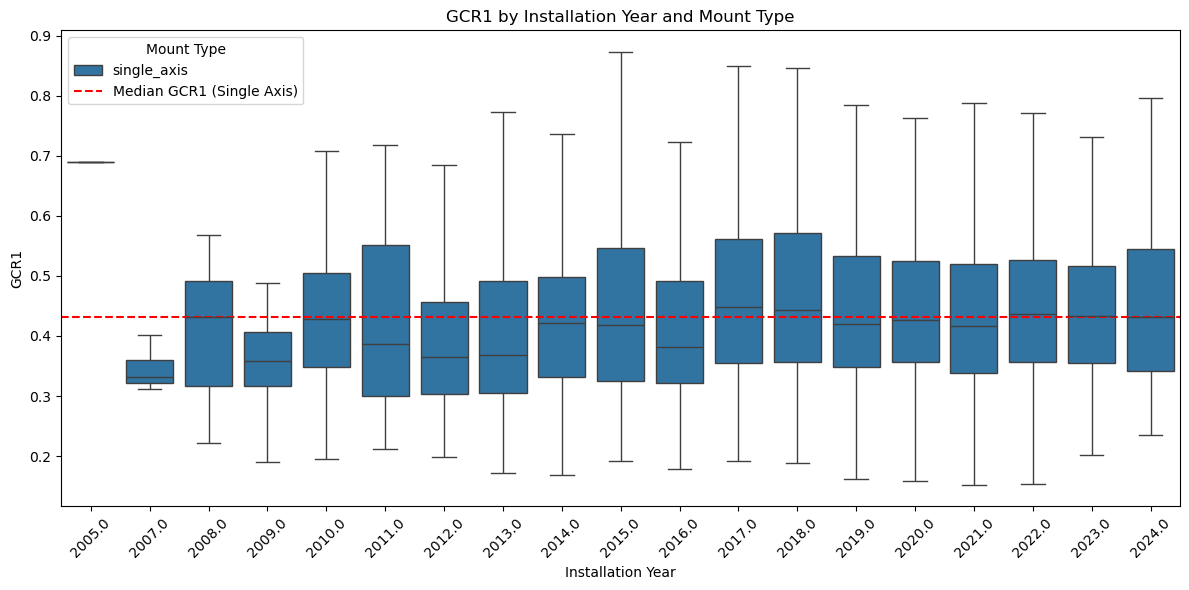

In [12]:
# Load GMSEUS arrays final
gmseusArraysFinal = gpd.read_file(gmseusArraysFinalPath)

# Subset for numRow >= 3 
gmseusArraysPlot = gmseusArraysFinal[gmseusArraysFinal['numRow'] >= minNumPanelRows]

# Drop rows with instYr < 2000
gmseusArraysPlot = gmseusArraysPlot[gmseusArraysPlot['instYr'] >= 2000]

# Subset for mountType (fixed_axis, single_axis, dual_axis)
gmseusArraysPlot = gmseusArraysPlot[gmseusArraysPlot['mount'].isin(['fixed_axis', 'single_axis', 'dual_axis'])]

# Subset for mountType (fixed_axis, single_axis, dual_axis)
gmseusArraysSingle = gmseusArraysPlot[gmseusArraysPlot['mount'] == 'single_axis']
gmseusArraysFixed = gmseusArraysPlot[gmseusArraysPlot['mount'] == 'fixed_axis']
gmseusArraysDual = gmseusArraysPlot[gmseusArraysPlot['mount'] == 'dual_axis']

# Plot using a yearsly boxplot for each mount type (GCR1) and remove outliers. Also, plot hline for the meadian GCR1 for 2024
plt.figure(figsize=(12, 6))
sns.boxplot(data=gmseusArraysSingle, x='instYr', y='GCR1', hue='mount', showfliers=False)
plt.axhline(y=gmseusArraysSingle[gmseusArraysSingle['instYr'] == 2024]['GCR1'].median(), color='r', linestyle='--', label='Median GCR1 (Single Axis)')
plt.title('GCR1 by Installation Year and Mount Type')
plt.xlabel('Installation Year')
plt.ylabel('GCR1')
plt.xticks(rotation=45)
plt.legend(title='Mount Type')
plt.tight_layout()
plt.show()

# Helper Functions

In [3]:
# Define a function to calculate the intersection over union of any two gdf datasets accounting for multiple potential intersections
def getIoU(gdf1, gdf2, panelRows = False):

    # If panelRows is false, explode, dissolve, and explode arrays
    if panelRows == False:
        # Explode both datasets into polygons, dissolve overlapping geometries, and explode again into spatially unique polygons
        gdf1 = gdf1.explode(index_parts=False).reset_index(drop=True)
        gdf2 = gdf2.explode(index_parts=False).reset_index(drop=True)
        gdf1 = gdf1.dissolve().reset_index(drop=True)
        gdf2 = gdf2.dissolve().reset_index(drop=True)
        gdf1 = gdf1.explode(index_parts=False).reset_index(drop=True)
        gdf2 = gdf2.explode(index_parts=False).reset_index(drop=True)
        # If panelRows is false, set minArrayArea to 45 square meters, else set to 15 square meters
        minArea = 45 # 45 square meters
    else:
        # If panelRows is true, set minArrayArea to 15 square meters
        minArea = 15 # 15 square meters

    # Drop all resulting polygons less than minArea
    gdf1['origArea_1'] = gdf1['geometry'].area
    gdf2['origArea_2'] = gdf2['geometry'].area

    # Drop all resulting polygons less than minArrayArea
    gdf1 = gdf1[gdf1['origArea_1'] > minArea].reset_index(drop=True)
    gdf2 = gdf2[gdf2['origArea_2'] > minArea].reset_index(drop=True)

    # Add a tempIOUid column to both datasets that is the index
    gdf1['tempIOUid_1'] = range(0, len(gdf1))
    gdf2['tempIOUid_2'] = range(0, len(gdf2))

    # Spatial join the two datasets, copying the tempIOUid_2 column to the gdf1 dataset
    intersections = gpd.sjoin(gdf1[['geometry', 'tempIOUid_1']], gdf2[['geometry', 'tempIOUid_2']], how='inner', predicate='intersects')

    # Perform the intersection operation to get the actual intersection geometries
    intersections['geometry'] = intersections.apply(lambda row: gdf1.loc[row['tempIOUid_1'], 'geometry'].intersection(gdf2.loc[row['tempIOUid_2'], 'geometry']), axis=1)

    # Now dissolve intersections by tempIOUid_1 and tempIOUid_2. 
    intersections = intersections.dissolve(by=['tempIOUid_1'], aggfunc='sum').reset_index()
    intersections = intersections.dissolve(by=['tempIOUid_2'], aggfunc='sum').reset_index()

    # Set an index column
    intersections['intIndex'] = intersections.index

    # Spatially join intersections to gdf1 and gdf2 saving intIndex
    gdf1 = gpd.sjoin(gdf1, intersections[['intIndex', 'geometry']], how='left', predicate='intersects')
    gdf2 = gpd.sjoin(gdf2, intersections[['intIndex', 'geometry']], how='left', predicate='intersects')

    # Drop rows from both where intIndex is NaN
    gdf1 = gdf1.dropna(subset=['intIndex'])
    gdf2 = gdf2.dropna(subset=['intIndex'])

    # Drop any columns containing the substring 'index'
    gdf1 = gdf1.loc[:, ~gdf1.columns.str.contains('index')]

    # Calculate areas and IoU
    gdf1['areaA'] = gdf1['geometry'].area
    gdf2['areaB'] = gdf2['geometry'].area

    # Aggregate areas for each intIndex
    gdf1_agg = gdf1.groupby('intIndex')['areaA'].sum().reset_index()
    gdf2_agg = gdf2.groupby('intIndex')['areaB'].sum().reset_index()

    # Merge aggregated areas into intersections
    intersections = intersections.merge(gdf1_agg, on='intIndex', how='left')
    intersections = intersections.merge(gdf2_agg, on='intIndex', how='left')

    # Calculate intersectionArea and unionArea
    intersections['intersectionArea'] = intersections['geometry'].area
    intersections['unionArea'] = (
        intersections['areaA'] +
        intersections['areaB'] -
        intersections['intersectionArea'])

    # Calculate IoU
    intersections['IoU'] = intersections['intersectionArea'] / intersections['unionArea']

    # Calculate the proportional difference in area between the two areas
    intersections['propDiff'] = (intersections['areaB'] - intersections['areaA']) / intersections['areaA']
    return intersections

# Function to check for and remove erroneous geometries in arrays
def checkArrayGeometries(arrays): 
    # For a collection of reasons, array boundaries may contain erroneous geometries that result in a near-zero area, linestrings, or points. 
    # To check for and remove these, we'll explode arrays, calculate a temporary area, remove subarrays that are less than a minimum area, then dissolve by tempID.
    arrays['tempDissolveID'] = (1 + np.arange(len(arrays)))  # Create a temporary ID for dissolving
    arrays = arrays.explode(index_parts=False)
    arrays['tempArea'] = arrays['geometry'].area
    arrays = arrays[arrays['tempArea'] >= minPanelRowArea]
    arrays = arrays.dissolve(by=['tempDissolveID'], as_index=False)
    arrays = arrays.drop(columns=['tempArea', 'tempDissolveID'])
    arrays = arrays.reset_index(drop=True)
    return arrays

# Function to create an array from a set of panel rows based on the distance between them
def createArrayFromPanels(panels, buffDist, dissolveID, areaID='area'):
 
    # Count panels per group before dissolving
    panelCounts = panels.groupby(dissolveID).size().reset_index(name='numPanels')

    # Get the total area of the panels within each group (sum of area column). 
    panelAreas = panels.groupby(dissolveID)[areaID].sum().reset_index(name='pnlArea')
    
    # Buffer the geometries by buffDist, dissovle boundaries, and unbuffer by buffDist* -1. Assign the number of objects being dissovle into a numPanels column.
    arrays = panels.copy()
    arrays['geometry'] = arrays.buffer(buffDist)
    arrays = arrays.dissolve(by=[dissolveID], as_index=False)
    arrays['geometry'] = arrays.buffer(buffDist * -1)

    # Merge the panel counts and panel areas back into the dissolved array DataFrame. Select only the dissolveID and respective columns in the right df
    arrays = arrays.merge(panelCounts[[dissolveID, 'numPanels']], on=dissolveID, how='left')
    arrays = arrays.merge(panelAreas[[dissolveID, 'pnlArea']], on=dissolveID, how='left')

    # Due to the buffering and unbuffering, some mulitpolygons contain erroneous geometries that result in a near-zero area, linestrings, or points. Remove these.
    arrays = checkArrayGeometries(arrays)

    # Reset index
    arrays = arrays.reset_index(drop=True)
    return arrays

# Get Manuscript Numeric Outputs

In [4]:
# Call gmseus arrays and panels
gmseusArrays = gpd.read_file(gmseusArraysFinalPath)
gmseusPanels = gpd.read_file(gmseusPanelsFinalPath)

## Abstract

In [5]:
# Print total number of arrays and panels
print('Total number of arrays: ', len(gmseusArrays))
print('Total number of panels: ', len(gmseusPanels))

# Print total area of arrays and panels (convert to km2)
print('Total area of arrays: ', gmseusArrays['totArea'].sum()/1e6)
print('Total area of panels: ', gmseusPanels['rowArea'].sum()/1e6)

# Print total sum of array capacity (convert from MW to GW)
print('Total sum of array capacity: ', gmseusArrays['capMW'].sum()/1e3)

Total number of arrays:  15017
Total number of panels:  2917782
Total area of arrays:  2944.2474049654306
Total area of panels:  466.0367335799997
Total sum of array capacity:  186.18105652000003


## Background & Summary

In [ ]:
# Print total number of arrays and sum array capacity for arrays with capacity > 1 (convert from MW to GW)
print('Total number of utility-scale arrays', len(gmseusArrays[gmseusArrays['capMW'] >= 1]))
print('Total sum of utility-scale array capacity: ', gmseusArrays[gmseusArrays['capMW'] >= 1]['capMW'].sum()/1e3)

# Print total number of arrays and sum array capacity for arrays with capacity < 1 (convert from MW to GW)
print('Total number of commercial-scale arrays', len(gmseusArrays[gmseusArrays['capMW'] < 1]))
print('Total sum of commercial-scale array capacity: ', gmseusArrays[gmseusArrays['capMW'] < 1]['capMW'].sum()/1e3)

# Print total number of arrays where numRow > 0 and total sum of array capacity (convert from MW to GW)
print('Total number of arrays with panel-rows: ', len(gmseusArrays[gmseusArrays['numRow'] > 0]))
print('Total sum of array capacity with panel-rows: ', gmseusArrays[gmseusArrays['numRow'] > 0]['capMW'].sum()/1e3)

# Print sum of gmseusPanel areas (convert to km2)
print('Total sum of panel areas: ', gmseusPanels['rowArea'].sum()/1e6)

# Print mount types and proportion of total array using using gmseusArrays, and consider any mount type containing the string 'mixed', as mixed (sum these in the proportiona) -- do not use append, use pd.concat
mountTypes = gmseusArrays['mount'].value_counts(normalize=True)
mixed_proportion = mountTypes[mountTypes.index.str.contains('mixed')].sum()
mountTypes = pd.concat([pd.Series({'mixed': mixed_proportion}), mountTypes[~mountTypes.index.str.contains('mixed')]])
mountTypes = mountTypes.sort_values(ascending=False)
print('Mount Type Proportions:')
print(mountTypes)

# Print median GCR1 values for each mount type where numRows > 3, considering all mixed mount types as mixed. Have to check numRows because we extrapolate GCR1 values for arrays with numRows = 0
# Get GCR relevant dataframe (numRow > 3 & modType != 'csp') -- we acquire GCR values for all arrays through spatial extrapolation (and actual estimation for CSP arrays), but this value is most relevant for PV arrays and with more than 3 rows
GCR1df = gmseusArrays[(gmseusArrays['numRow'] > 3) & (gmseusArrays['modType'] != 'csp')]
mountGCR1 = GCR1df.groupby('mount')['GCR1'].median()
mixedGCR1 = GCR1df[gmseusArrays['mount'].str.contains('mixed')]['GCR1'].median()
mountGCR1 = pd.concat([pd.Series({'mixed': mixedGCR1}), mountGCR1[~mountGCR1.index.str.contains('mixed')]])
mountGCR1 = mountGCR1.sort_values(ascending=False)
print('Median GCR1 values:')
print(mountGCR1)

Total number of utility-scale arrays 9631
Total sum of utility-scale array capacity:  184.16597142929444
Total number of commercial-scale arrays 5386
Total sum of commercial-scale array capacity:  2.0150850907055493
Total number of arrays with panel-rows:  9042
Total sum of array capacity with panel-rows:  83.0854483550119
Total sum of panel areas:  466.0367335799997
Mount Type Proportions:
fixed_axis     0.419325
unknown        0.325631
single_axis    0.207631
mixed          0.026104
dual_axis      0.021309
dtype: float64
Median GCR1 values:
mixed          0.62845
fixed_axis     0.52865
dual_axis      0.49575
single_axis    0.41590
dtype: float64


f:\Python_Envs\BigPanel\Lib\site-packages\geopandas\geodataframe.py:1459: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


## Methods

In [7]:
# Print total number of arrays where Source == "GMSEUSgeorect"
print('Total number of arrays from GMSEUSgeorect: ', len(gmseusArrays[gmseusArrays['Source'] == 'GMSEUSgeorect']))

# Print the value counts for gmseusPanels Source
print(gmseusPanels['Source'].value_counts())

# Print the total number of arrays with newBound = 1, and the sum of the totArea for these arrays
print('Total number of arrays with newBound = 1: ', len(gmseusArrays[gmseusArrays['newBound'] == 1]))
print('Total sum of totArea for arrays with newBound = 1: ', gmseusArrays[gmseusArrays['newBound'] == 1]['totArea'].sum()/1e6)

# Call exisintArrayShapes, get existing arrays that intersect with gmseusArrays where newBound = 1
existingArrayShapes = gpd.read_file(os.path.join(derivedTemp_path, r'existingDatasetArrayShapes.shp'))
existingArrayShapesOldBounds = gpd.sjoin(existingArrayShapes, gmseusArrays[gmseusArrays['newBound'] == 1], how='left', predicate='intersects')
existingArrayShapesOldBounds = existingArrayShapesOldBounds.dropna(subset=['index_right'])
existingArrayShapesOldBounds = existingArrayShapesOldBounds.reset_index(drop=True)
print('Sum of area for existing arrays with newBound = 1: ', existingArrayShapesOldBounds['area'].sum()/1e6)

Total number of arrays from GMSEUSgeorect:  34
Source
gmseus    1846710
OSM        867985
CCVPV      203087
Name: count, dtype: int64
Total number of arrays with newBound = 1:  5017
Total sum of totArea for arrays with newBound = 1:  174.163928
Sum of area for existing arrays with newBound = 1:  280.528801341833


## Technical Validation

### Dataset completeness compared to other datasets

In [4]:
# SEIA and Wood Mackenzie information from https://seia.org/research-resources/us-solar-market-insight/ and https://seia.org/research-resources/solar-market-insight-report-q4-2024/
# Set SEIA and Wood Mackenzie values
totInstall2024 = 219 # GW, from report, total from plot was 213.25
totInstallNonRes2024 = 174.18 # GW, From their plot 2014 - 2024
totInstallNonRes2023 = 138.78 # GW, From their plot 2014 - 2023

# Pull GMSEUS and USPVDB and TZSAM
gmseusArrays = gpd.read_file(gmseusArraysFinalPath)
uspvdb = gpd.read_file(uspvdb_path)
sam = gpd.read_file(sam_path)

# Call uspvdb and prepare dataframe for ILR calculation
USPVDB_path = os.path.join(downloaded_path, r'SolarDB/USPVDB/uspvdb_v2_0_20240801.shp')
uspvdbDownload = gpd.read_file(USPVDB_path)
uspvdbDownload = uspvdbDownload.dropna(subset=['p_cap_ac', 'p_cap_dc']) # Drop rows where p_cap_ac or p_cap_dc is NaN
uspvdbDownload['p_cap_ratio'] = uspvdbDownload['p_cap_dc'] / uspvdbDownload['p_cap_ac'] # Calculate the ratio of p_cap_dc to p_cap_ac
medILR = uspvdbDownload['p_cap_ratio'].median() # Get median value

# TZSAM uses MWac, so convert to MWdc using USPVDB median ILR (AC * DC/AC = DC)
sam['cap_mwDC'] = sam['cap_mw'] * medILR

# Print sum of cap_mw for uspvdb and sam and convert to GW. Then, calcualte the proportion of totInstallNonRes
print('Sum of MWdc for USPVDB: ', uspvdb['cap_mw'].sum()/1e3)
print('Sum of MWac for SAM: ', sam['cap_mw'].sum()/1e3)
print('Sum of MWdc for SAM: ', sam['cap_mwDC'].sum()/1e3)
print('Proportion of USPVDB Capacity to SEIA 2023 NonRes: ', uspvdb['cap_mw'].sum()/1e3/totInstallNonRes2023)
print('Proportion of SAM Capacity to SEIA 2024 NonRes: ', sam['cap_mwDC'].sum()/1e3/totInstallNonRes2024)

# Print proprtion of sam to totInstall2024
print('Proportion of SAM to all 2024: ', sam['cap_mwDC'].sum()/1e3/totInstall2024)

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ TZ-SAM Area and Capacity Bias Reporting

# For area bias, CHECK SPATIAL VALIDATION CODE BELOW

# Defined a function to calculate the proportional difference in a variable between two datasets
def proportionalDifference(gdf1, gdf2, gdf1Col, gdf2Col): 
    # Set uniqueID columns
    gdf1['uniqueID1'] = range(0, len(gdf1))
    gdf2['uniqueID2'] = range(0, len(gdf2))

    # Rename gdf1Col and gdf2Col to COI1 and COI2 - avoid join renaming conflicts
    gdf1 = gdf1.rename(columns={gdf1Col: 'COI1'})
    gdf2 = gdf2.rename(columns={gdf2Col: 'COI2'})

    # Select only uniqueID, geometry, and COI columns
    gdf1 = gdf1[['uniqueID1', 'COI1', 'geometry']]
    gdf2 = gdf2[['uniqueID2', 'COI2', 'geometry']]

    # Perform a spatial join between uspvdb and sam and drop NaN values where no intersect happens
    intersection = gpd.sjoin(gdf1, gdf2, how='inner', predicate='intersects')
    intersection = intersection.dropna(subset=['uniqueID2'])

    # Dissolve by usvpdbID and samID
    intersection = intersection.dissolve(by=['uniqueID1']).reset_index()
    intersection = intersection.dissolve(by=['uniqueID2']).reset_index()

    # Add unique intersectID column
    intersection['intersectID'] = range(0, len(intersection))

    # Now, spatially join the intersection to uspvdb and sam
    gdf1Intersection = gpd.sjoin(gdf1, intersection[['intersectID', 'geometry']], how='left', predicate='intersects')
    gdf2Intersection = gpd.sjoin(gdf2, intersection[['intersectID', 'geometry']], how='left', predicate='intersects')

    # Group both dataframes by intersectID and sum the capacity
    gdf1Intersection = gdf1Intersection.groupby('intersectID')['COI1'].sum().reset_index()
    gdf2Intersection = gdf2Intersection.groupby('intersectID')['COI2'].sum().reset_index()

    # Drop all columns in intersection except intersectID
    intersection = intersection[['intersectID', 'geometry']].copy()

    # Merge the capacity back into the intersection dataframe
    intersection = intersection.merge(gdf1Intersection, on='intersectID', how='left')
    intersection = intersection.merge(gdf2Intersection, on='intersectID', how='left')

    # Calculate the proportional difference in capacity between the two datasets
    intersection['propDiff'] = (intersection['COI2'] - intersection['COI1']) / intersection['COI1']

    return intersection

# Calculate the proportional difference in capacity between uspvdb and sam
capacityBias = proportionalDifference(uspvdb, sam, 'cap_mw', 'cap_mwDC')

# Print both 
print('TZ-SAM Capacity Bias (%): ', capacityBias['propDiff'].median())

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ GMSEUS 

# Print Sum of GMSEUS capMW converted to GW, then calculate the proportion of GMSEUS to totInstallNonRes
print('Sum of GMSEUS Capacity (GW): ', gmseusArrays['capMW'].sum()/1e3)
print('Proportion of GMSEUS Capacity to SEIA 2024 NonRes (%): ', gmseusArrays['capMW'].sum()/1e3/totInstallNonRes2024*100)
print('Proportion of GMSEUS Capacity to SEIA 2024 all cap (%): ', gmseusArrays['capMW'].sum()/1e3/totInstall2024*100)

# Print the number of gmseus arrays with numRow > 0
print('Number of GMSEUS arrays with numRow > 0: ', len(gmseusArrays[gmseusArrays['numRow'] > 0]))

# Get gmseus arrays with numRow > 0 that do not intersect with uspvdb
uspvdb['intersectID'] = range(0, len(uspvdb))
gmseusWithPanelRows = gmseusArrays[gmseusArrays['numRow'] > 0]
gmseusWithPanelRowsInUSPVDB = gpd.sjoin(gmseusWithPanelRows, uspvdb[['geometry', 'intersectID']], how='left', predicate='intersects')
gmseusWithPanelRowsInUSPVDB = gmseusWithPanelRowsInUSPVDB.dropna(subset=['intersectID']) # Drop null values in intersectID

# Drop gmseusWithPanelRows where arrayID is in gmseusWithPanelRowsInUSPVDB
gmseusWithPanelRows = gmseusWithPanelRows[~gmseusWithPanelRows['arrayID'].isin(gmseusWithPanelRowsInUSPVDB['arrayID'])]

# Print the number of gmseus arrays with numRow > 0 that do not intersect with uspvdb and the sum of their capMW (convert to GW)
print('Number of GMSEUS arrays with numRow > 0 that do not intersect with USPVDB: ', len(gmseusWithPanelRows))
print('Sum of GMSEUS Capacity with numRow > 0 that do not intersect with USPVDB (GW): ', gmseusWithPanelRows['capMW'].sum()/1e3)

# Print the difference between totInstallNonRes2024 and gmseusArrays capMW sum
print('Difference between SEIA 2024 NonRes and GMSEUS Capacity (GW): ', totInstallNonRes2024 - gmseusArrays['capMW'].sum()/1e3)


Sum of MWdc for USPVDB:  90.35383999999999
Sum of MWac for SAM:  196.95527954763895
Sum of MWdc for SAM:  256.8981907143117
Proportion of USPVDB Capacity to SEIA 2023 NonRes:  0.6510580775327857
Proportion of SAM Capacity to SEIA 2024 NonRes:  1.474900624149223
Proportion of SAM to all 2024:  1.1730510991521081
TZ-SAM Capacity Bias (%):  0.2961301100013121
Sum of GMSEUS Capacity (GW):  186.18105652000003
Proportion of GMSEUS Capacity to SEIA 2024 NonRes (%):  106.89003130095304
Proportion of GMSEUS Capacity to SEIA 2024 all cap (%):  85.01418105936074
Number of GMSEUS arrays with numRow > 0:  9042
Number of GMSEUS arrays with numRow > 0 that do not intersect with USPVDB:  5858
Sum of GMSEUS Capacity with numRow > 0 that do not intersect with USPVDB (GW):  16.682248355011904
Difference between SEIA 2024 NonRes and GMSEUS Capacity (GW):  -12.00105652000002


### Attribute Validation

In [7]:
# # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Mount, Azimuth, and Tilt

# Call all three validaiton dataframes from intermediateProducts and script7
mountValid = gpd.read_file(os.path.join(derivedTemp_path, r'GMSEUS_Arrays_wMount_valid.shp'))
azimuthValid = gpd.read_file(os.path.join(derivedTemp_path, r'GMSEUS_Arrays_wAzimuth_valid.shp'))
tiltValid = gpd.read_file(os.path.join(derivedTemp_path, r'GMSEUS_Arrays_wTilt_valid.shp'))

# Subset each validation dataframe to only include UPSVDB Source
mountValid = mountValid[mountValid['Source'] == 'USPVDB']
azimuthValid = azimuthValid[azimuthValid['Source'] == 'USPVDB']
tiltValid = tiltValid[tiltValid['Source'] == 'USPVDB']

# # # Print colnames for each (since valid column likely got sliced off due to shp file header limitations)
# # print('Mount Valid Columns: ', mountValid.columns)
# print('Azimuth Valid Columns: ', azimuthValid.columns)
# print('Tilt Valid Columns: ', tiltValid.columns)

# MOUNT VALIDATION: Get mountValid rows where mount column is the same as mount_vali column, and get proportion of total rows in mountValid
mountValidMatch = mountValid[mountValid['mount'] == mountValid['mount_vali']]
mountValidProp = len(mountValidMatch)/len(mountValid)
print('Number of potential mountValid rows: ', len(mountValid))
print('Proportion of mountValid rows where mount column matches mount_vali column: ', mountValidProp)

# AZIMUTH VALIDATION: Get azimuthValid rows where avgAzimuth column is within (+/-) 15 degrees of avgAzimu_1 column, and get proportion of total rows in azimuthValid
plusOrMinusAzimuth = 15
azimuthValid['azimuthDiff'] = azimuthValid['avgAzimuth'] - azimuthValid['avgAzimu_1']
azimuthValidMatch = azimuthValid[(azimuthValid['azimuthDiff'] >= plusOrMinusAzimuth*-1) & (azimuthValid['azimuthDiff'] <= plusOrMinusAzimuth)]
azimuthValidProp = len(azimuthValidMatch)/len(azimuthValid)
print('Number of potential azimuthValid rows: ', len(azimuthValid))
print('Proportion of azimuthValid rows where avgAzimuth column is within 15 degrees of avgAzimu_1 column: ', azimuthValidProp)

# TILT VALIDATION: Get tiltValid rows where avgTilt column is within (+/-) 5 degrees of avgTilt_1 column, and get proportion of total rows in tiltValid
plusOrMinusTilt = 5
tiltValid['tiltDiff'] = tiltValid['tilt'] - tiltValid['tiltEst']
tiltValidMatch = tiltValid[(tiltValid['tiltDiff'] >= plusOrMinusTilt*-1) & (tiltValid['tiltDiff'] <= plusOrMinusTilt)]
tiltValidProp = len(tiltValidMatch)/len(tiltValid)
print('Number of potential tiltValid rows: ', len(tiltValid))
print('Proportion of tiltValid rows where avgTilt column is within 5 degrees of avgTilt_1 column: ', tiltValidProp)


Number of potential mountValid rows:  3147
Proportion of mountValid rows where mount column matches mount_vali column:  0.9205592627899587
Number of potential azimuthValid rows:  3147
Proportion of azimuthValid rows where avgAzimuth column is within 15 degrees of avgAzimu_1 column:  0.8859231013663806
Number of potential tiltValid rows:  1985
Proportion of tiltValid rows where avgTilt column is within 5 degrees of avgTilt_1 column:  0.11788413098236776


# Plots Technical Validation

## Set Themes

In [65]:
# Set some colors 
darkGreyTheme = '#3D3D3D'

## LandTrendr Installation Year

In [5]:
# Call gmseusArrays
gmseusArrays = gpd.read_file(gmseusArraysFinalPath)

# Set plot df (Source 'USPVDB' or 'CCVPV')
plotdf = gmseusArrays[gmseusArrays['Source'].isin(['USPVDB'])]

# Calculate the deviation
plotdf['deviation'] = plotdf['instYrLT'] - plotdf['instYr']

# Remove any rows where instYrLT is -9999 or instYr is -9999
lt_data_noNull = plotdf[(plotdf['instYrLT'] != -9999) & (plotdf['instYr'] != -9999)]

# Drop rows where Source is anything other than USPVDB
lt_data_noNull = lt_data_noNull[lt_data_noNull['Source'] == 'USPVDB']

# Set instYr to integer
lt_data_noNull['instYr'] = lt_data_noNull['instYr'].astype(int)

# Print the total number of arrays with a newly detected installation year
print('Number of arrays with a newly detected installation year:', lt_data_noNull['deviation'].value_counts().sum())

# Print the proportion of arrays where abs(deviation) is equal to or less than 1
print('Proportion of arrays within one year of observed installation:', len(lt_data_noNull[lt_data_noNull['deviation'].abs() <= 1])/len(lt_data_noNull))

# Print the proportion of arrays where abs(deviation) is equal to or less than 2
print('Proportion of arrays within two years of observed installation:', len(lt_data_noNull[lt_data_noNull['deviation'].abs() <= 2])/len(lt_data_noNull))

# Print the mean absolute deviation
instYrMAE = lt_data_noNull['deviation'].abs().mean()
print('Mean Absolute Error:', )

# Drop rows where instYr < 2009
lt_data_noNull = lt_data_noNull[lt_data_noNull['instYr'] >= 2009]

# Count the number of observations for each year
counts = lt_data_noNull.groupby('instYr')['deviation'].count()

Number of arrays with a newly detected installation year: 4151
Proportion of arrays within one year of observed installation: 0.6627318718381113
Proportion of arrays within two years of observed installation: 0.7973982172970369
Mean Absolute Error:


f:\Python_Envs\BigPanel\Lib\site-packages\geopandas\geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


f:\Python_Envs\BigPanel\Lib\site-packages\seaborn\categorical.py:700: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  artists = ax.bxp(**boxplot_kws)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


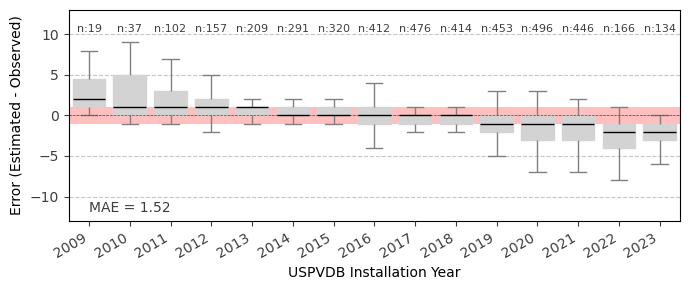

In [15]:
# Plot the boxplot with seaborn
plt.figure(figsize=(7, 3))
gray_shade = "lightgray"  # Color for boxplots

# Add a shaded black region for ±1 year deviation (set border width to none)
plt.axhspan(-1, 1, color='red', alpha=0.25, lw=0) # , label='±1 Year Deviation'

# Create the boxplot
sns.boxplot(
    x='instYr',
    y='deviation',
    data=lt_data_noNull,
    boxprops=dict(color=gray_shade),  # Apply gray shade to boxplots
    whiskerprops=dict(color="gray"),  # Make whiskers dark gray
    capprops=dict(color="gray"),  # Make caps dark gray
    medianprops=dict(color="black"),  # Ensure median line is black
    showfliers=False)

# Add the count (N) above each box
for i, (year, count) in enumerate(counts.items()):
    plt.text(i, 10, f'n:{count}', ha='center', va='bottom', fontsize=8, color=darkGreyTheme)

# Add annotations for MAE and missing arrays in the lower-left corner
plt.text(0, -10.5, f'MAE = {instYrMAE:.2f}', ha='left', va='top', fontsize=10, color=darkGreyTheme)

# Set x and y limits
plt.ylim(-13, 13)

# Add labels, title, and grid
plt.xlabel('USPVDB Installation Year', fontsize=10, color='black')
plt.ylabel('Error (Estimated - Observed)', fontsize=10, color='black')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust x-axis text angle to 30 degrees with custom alignment
plt.xticks(rotation=30, ha='right')

# Add a 0 line (no deviation)
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.5) # , label='No Deviation'

# Add a legend with text color updated
legend = plt.legend(fontsize=8, frameon=False)
for text in legend.get_texts():
    text.set_color(darkGreyTheme)

# Set axis tick colors
plt.tick_params(axis='x', colors=darkGreyTheme)
plt.tick_params(axis='y', colors=darkGreyTheme)

# Final layout adjustments and show plot
plt.tight_layout()

# Export
plt.savefig(os.path.join(figure_path, 'instYrAccuracy.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_path, 'instYrAccuracy.pdf'), dpi=300, bbox_inches='tight')

# Show plot
plt.show()

## Installed Capacity

In [19]:
# Call gmseusArrays and CCVPV arrays
gmseusArrays = gpd.read_file(gmseusArraysFinalPath)

# Call USPVDB
uspvdb = gpd.read_file(uspvdb_path)

# Call solarPaces, USS, GSPT, and GPPDB
solarPacesPath = os.path.join(derivedTemp_path, r'solarPaces_point.shp')
lbnlUssPath = os.path.join(derivedTemp_path, r'lbnlUss_point.shp')
gsptPath = os.path.join(derivedTemp_path, r'gspt_point.shp')
gppdbPath = os.path.join(derivedTemp_path, r'gppdb_point.shp')
solarPaces = gpd.read_file(solarPacesPath)
lbnlUss = gpd.read_file(lbnlUssPath)
gspt = gpd.read_file(gsptPath)
gppdb = gpd.read_file(gppdbPath)

# Subset all datasets for modType == 'csp'
solarPacesCSP = solarPaces[solarPaces['modType'] == 'csp']
lbnlUssCSP = lbnlUss[lbnlUss['modType'] == 'csp']
gsptCSP = gspt[gspt['modType'] == 'csp']
gppdbCSP = gppdb[gppdb['modType'] == 'csp']

# Subset for modType == 'csp'
gmseusArraysCSP = gmseusArrays[gmseusArrays['modType'] == 'csp']

In [20]:
# Print sum of cam_mw for all datasets
print('Sum of GMSEUS CSP Capacity (MW): ', gmseusArraysCSP['capMW'].sum()/1e3)
print('Sum of solarPaces CSP Capacity (MW): ', solarPacesCSP['cap_mw'].sum()/1e3)
print('Sum of lbnlUss CSP Capacity (MW): ', lbnlUssCSP['cap_mw'].sum()/1e3)
print('Sum of gspt CSP Capacity (MW): ', gsptCSP['cap_mw'].sum()/1e3)
print('Sum of gppdb CSP Capacity (MW): ', gppdbCSP['cap_mw'].sum()/1e3)

# Print the number of arrays in gmseusArraysCSP where capMW != capMWest
print('Number of GMSEUS CSP arrays where capMW != capMWest: ', len(gmseusArraysCSP[gmseusArraysCSP['capMW'] != gmseusArraysCSP['capMWest']]))

Sum of GMSEUS CSP Capacity (MW):  1.9649829686069327
Sum of solarPaces CSP Capacity (MW):  1.505
Sum of lbnlUss CSP Capacity (MW):  1.7739
Sum of gspt CSP Capacity (MW):  1.8126000000000002
Sum of gppdb CSP Capacity (MW):  0.0
Number of GMSEUS CSP arrays where capMW != capMWest:  15


In [ ]:

gspt_path = os.path.join(downloaded_path, r'SolarDB\GSPT\Global-Solar-Power-Tracker-June-2024.xlsx')

# Read the second and third sheets of the excel file (first is an about page)
gspt2 = pd.read_excel(gspt_path, sheet_name=1)  # Second sheet (<20 MW)
gspt3 = pd.read_excel(gspt_path, sheet_name=2)  # Third sheet (>20 MW)

# Combine the dataframes
gspt = pd.concat([gspt2, gspt3], ignore_index=True)

# Subset for the United States from Country/Area column
gspt = gspt[gspt['Country/Area'] == 'United States']

# Subset for Status = 'operating', Location accuracy is = 'exact', and Start year is less than or equal to mostRecentInstallYear
gspt = gspt[gspt['Status'] == 'operating']
print(f'The number of gspt arrays where location accuracy is not exact is {len(gspt[gspt["Location accuracy"] != "exact"])}') # Print the number of gspt where location accuracy is not exact 

# Create a centroid shape file from the Latitude and Longitude columns
gspt['geometry'] = gpd.points_from_xy(gspt['Longitude'], gspt['Latitude'])

# Convert to GeoDataFrame and transform to projection of USPVDB
gspt = gpd.GeoDataFrame(gspt, geometry='geometry', crs=4326)

# Set Technology Type as modType
gspt['modType'] = gspt['Technology Type'].str.lower()

# If modType contains 'pv', set to c-si. If modType contains 'thermal', set to csp. Else, set to c-si. 
gspt.loc[gspt['modType'].str.contains('pv', case=False, na=False), 'modType'] = 'c-si'
gspt.loc[gspt['modType'].str.contains('thermal', case=False, na=False), 'modType'] = 'csp'
gspt.loc[~gspt['modType'].isin(['c-si', 'csp']), 'modType'] = 'c-si'

The number of gspt arrays where location accuracy is not exact is 54


In [27]:
# Print first 14 rows of gspt where modType is csp. Print only Capacity Rating column
print(gspt[gspt['modType'] == 'csp'].head(14)[['Capacity Rating']])

      Capacity Rating
5310             MWac
5542             MWac
5543             MWac
5755             MWac
5756             MWac
5757             MWac
5924             MWac
5985             MWac
5986             MWac
6041             MWac
6428             MWac
6429             MWac
6438             MWac
27603            MWac


Sum of capMW for gmseusArraysCSP:  1.1750829686069326
Sum of capMWest for gmseusArraysCSP:  10.720845


NameError: name 'darkGreyTheme' is not defined

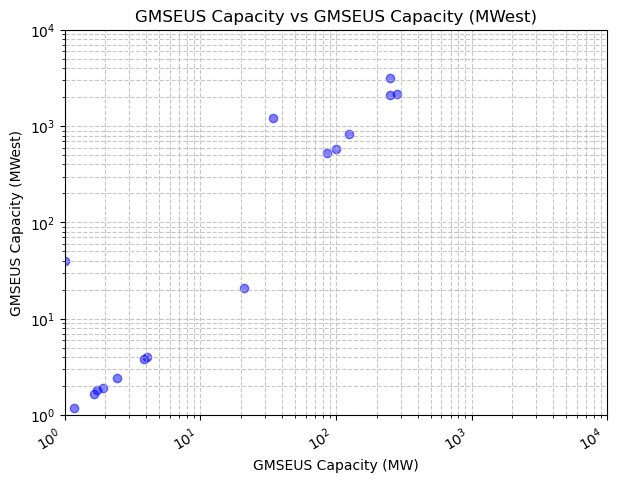

In [9]:
# Print the sum of capMW and capMWest for gmseusArraysCSP
print('Sum of capMW for gmseusArraysCSP: ', gmseusArraysCSP['capMW'].sum()/1e3)
print('Sum of capMWest for gmseusArraysCSP: ', gmseusArraysCSP['capMWest'].sum()/1e3)

# Subset arrays that the difference between capMW and capMWest is less than 10% of capMW
gmseusArraysCSP = gmseusArraysCSP[gmseusArraysCSP['capMW'] - gmseusArraysCSP['capMWest'] < gmseusArraysCSP['capMW'] * 0.00001]

# Plot a log-log scatterplot of capMW vs capMWest
plt.figure(figsize=(7, 5))
plt.scatter(gmseusArraysCSP['capMW'], gmseusArraysCSP['capMWest'], alpha=0.5, color='blue')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('GMSEUS Capacity (MW)', fontsize=10, color='black')
plt.ylabel('GMSEUS Capacity (MWest)', fontsize=10, color='black')
plt.title('GMSEUS Capacity vs GMSEUS Capacity (MWest)', fontsize=12, color='black')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.5) # , label='No Deviation'
plt.axvline(x=0, color='red', linestyle='--', linewidth=0.5) # , label='No Deviation'
plt.xlim(1, 1e4) # Set x-axis limits
plt.ylim(1, 1e4) # Set y-axis limits
plt.xticks(rotation=30, ha='right')
plt.tick_params(axis='x', colors=darkGreyTheme)
plt.tick_params(axis='y', colors=darkGreyTheme)
plt.tight_layout()
plt.show()

In [66]:
# Call gmseusArrays and CCVPV arrays
gmseusArrays = gpd.read_file(gmseusArraysFinalPath)

# Print the number of CSP arrays
print('Number of CSP arrays:', gmseusArrays[gmseusArrays['modType'] == 'csp'].shape[0])

# Print the number of CSP arrays that are mount = single_axis
print('Number of CSP arrays that are single axis:', gmseusArrays[(gmseusArrays['modType'] == 'csp') & (gmseusArrays['mount'] == 'single_axis')].shape[0])

# Print mount type counts for CSP arrays
print('CSP Mount Type Counts:')
print(gmseusArrays[gmseusArrays['modType'] == 'csp']['mount'].value_counts())

Number of CSP arrays: 74
Number of CSP arrays that are single axis: 11
CSP Mount Type Counts:
mount
fixed_axis     32
dual_axis      18
single_axis    11
mixed_df        7
unknown         5
mixed_ds        1
Name: count, dtype: int64


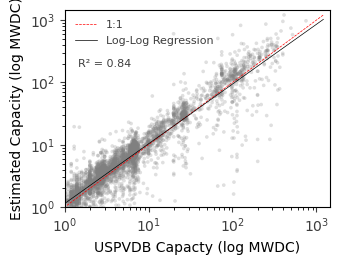

In [89]:
# Call gmseusArrays and CCVPV arrays
gmseusArrays = gpd.read_file(gmseusArraysFinalPath)

# First version of plotdf (Source = 'USPVDB')
plotdf1 = gmseusArrays[gmseusArrays['Source'].isin(['USPVDB'])]

# Prepare plot
plt.figure(figsize=(3.5,2.75))

# Right Plot: Scatterplot for areaA (x) and areaB (y) in log-log scale (I want no edge color). Set size to 0.3
plt.scatter(plotdf1['capMW'], plotdf1['capMWest'], alpha=0.25, edgecolors='none', color='gray', s=7)

# Add reference line (y=x) for comparison
max_val = max(plotdf1['capMW'].max(), plotdf1['capMWest'].max())
min_val = min(plotdf1['capMW'].min(), plotdf1['capMWest'].min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=0.5, label='1:1')

# Get the loglog R2 value and add it in the upper left corner
plotdf1 = plotdf1[(plotdf1['capMW'] > 0) & (plotdf1['capMWest'] > 0)]
r2 = np.corrcoef(np.log10(plotdf1['capMW']), np.log10(plotdf1['capMWest']))[0, 1] ** 2
plt.text(0.05, 0.75, f'R² = {r2:.2f}', transform=plt.gca().transAxes, ha='left', va='top', fontsize=8, color=darkGreyTheme)

# Add loglog linear regression line
slope, intercept = np.polyfit(np.log10(plotdf1['capMW']), np.log10(plotdf1['capMWest']), 1)
plt.plot([min_val, max_val], [10**intercept * min_val ** slope, 10**intercept * max_val ** slope], color='black', linestyle='-', linewidth=0.5, label='Log-Log Regression')

# Add legend in the upper left and set text color
legend = plt.legend(loc='upper left', frameon=False, fontsize=8)
for text in legend.get_texts():
    text.set_color(darkGreyTheme)  # Set legend text color to #3D3D3D

# Set log-log scale
plt.xscale('log')
plt.yscale('log')

# Add labels, title, and format axes
plt.xlabel('USPVDB Capacity (log10[MWDC])', fontsize=10, color='black')
plt.ylabel('Estimated Capacity (log10[MWDC])', fontsize=10, color='black')
plt.xlim([1, max_val * 1.2])
plt.ylim([1, max_val * 1.2])

# Set tick params to darkGreyTheme
plt.tick_params(axis='x', colors=darkGreyTheme)
plt.tick_params(axis='y', colors=darkGreyTheme)

# Tight layout
plt.tight_layout()

# Export
plt.savefig(os.path.join(figure_path, 'capacityValidation.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_path, 'capacityValidation.pdf'), dpi=300, bbox_inches='tight')

# Show plot
plt.show()

## Ground Cover Ratio

In [114]:
# ~~~~~~~~~~~~~~~~~~~~~~~ GMSEUS

# Call gmseusArrays and CCVPV arrays
gmseusArrays = gpd.read_file(gmseusArraysFinalPath)

# Select gmseusArrays where modType is not csp
gmseusArrays = gmseusArrays[gmseusArrays['modType'] != 'csp']

# Subset for gmseusArrays where numRow > 0
gmseusArrays = gmseusArrays[gmseusArrays['numRow'] > 3]

# For the purpose of this plot, if mount contains "mixed_", set mount type as mixed
gmseusArrays.loc[gmseusArrays['mount'].str.contains('mixed_'), 'mount'] = 'mixed'

# Print median GCR1 and GCR2 values for each mount type
print(gmseusArrays.groupby('mount')[['GCR1', 'GCR2']].median())

# Melt GCR1 and GCR2 from gmseusArrays for plotting
gcr_melted = gmseusArrays.melt(
    id_vars='mount',
    value_vars=['GCR1', 'GCR2'],
    var_name='Dataset',
    value_name='Value')

# Print the number of arrays with each mount type
print(gmseusArrays['mount'].value_counts())

# ~~~~~~~~~~~~~~~~~~~~~~~ CCVPV

# Call ccvpvArrays
ccvpv = gpd.read_file(ccvpvInitArraysPath)

# Drop erronous PF values (< 0 and > 1)
ccvpv = ccvpv[(ccvpv['PF'] >= 0) & (ccvpv['PF'] <= 1)]

# Set a mount column. If Class is 'Si_Fixed_S', set to fixed_axis. If Class is 'Si_Single_E/W', set to single_axis. 
ccvpv['mount'] = np.nan
ccvpv['mount'] = ccvpv['mount'].astype(object)
ccvpv.loc[ccvpv['Class'] == 'Si_Fixed_S', 'mount'] = 'fixed_axis'
ccvpv.loc[ccvpv['Class'] == 'Si_Single_E/W', 'mount'] = 'single_axis'

# Melt PF values from ccvpvArrays for plotting
ccvpv_melted = ccvpv.melt(
    id_vars='mount',
    value_vars=['PF'],
    var_name='Dataset',
    value_name='Value'
)

# Update the Dataset column to label PF data
ccvpv_melted['Dataset'] = 'CCVPV'

# Print the number of arrays with each mount type
print(ccvpv['mount'].value_counts())

# ~~~~~~~~~~~~~~~~~~~~~~~ Ong et al., 2013

# Define the Ong et al., 2013 boxplot statistics
ong_data = {
    'mount': ['fixed_axis', 'single_axis', 'dual_axis'],
    'Min': [0.31, 0.20, 0.13],
    'Q1': [0.45, 0.32, 0.21],
    'Median': [0.51, 0.36, 0.22],
    'Q3': [0.59, 0.45, 0.23],
    'Max': [0.92, 0.51, 0.32]}
ong_df = pd.DataFrame(ong_data)

# Function to generate synthetic data based on boxplot statistics
def generate_synthetic_data(row, size=100):
    min_val, q1, median, q3, max_val = row['Min'], row['Q1'], row['Median'], row['Q3'], row['Max']
    lower_whisker = np.random.uniform(min_val, q1, size // 4)  # Values between Min and Q1
    iqr = np.random.uniform(q1, q3, size // 2)                # Values between Q1 and Q3
    upper_whisker = np.random.uniform(q3, max_val, size // 4) # Values between Q3 and Max
    return np.concatenate([lower_whisker, iqr, upper_whisker])

# Generate synthetic data for each mount type in Ong's dataset
synthetic_ong_data = []
for _, row in ong_df.iterrows():
    data = generate_synthetic_data(row)
    synthetic_ong_data.append(pd.DataFrame({
        'mount': row['mount'],
        'Value': data,
        'Dataset': 'Ong'}))

# Combine synthetic Ong data into a single DataFrame
synthetic_ong_df = pd.concat(synthetic_ong_data, ignore_index=True)

# ~~~~~~~~~~~~~~~~~~~~~~~ Plotting

# Combine the GMSEUS, CCVPV, and Ong et al., 2013 data
combined_df = pd.concat([gcr_melted, ccvpv_melted, synthetic_ong_df], ignore_index=True)

                GCR1     GCR2
mount                        
dual_axis    0.49575  0.62895
fixed_axis   0.52865  0.57890
mixed        0.62845  0.63370
single_axis  0.41590  0.55600
mount
fixed_axis     5282
single_axis    2583
mixed           298
dual_axis       230
Name: count, dtype: int64
mount
fixed_axis     639
single_axis    360
Name: count, dtype: int64


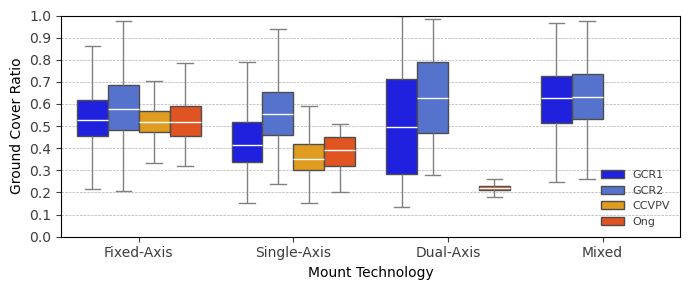

In [117]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# Plot the combined dataset. Change x-axis names to 'Fixed-Axis', 'Single-Axis', and 'Dual-Axis'.
# Set dataset colors (GCR1: greyblue, GCR2: lightblue, CCVPV: orange, Ong: red). Make boxplot median a white line
plt.figure(figsize=(7, 3))
sns.boxplot(
    x='mount',
    y='Value',
    data=combined_df,
    hue='Dataset',
    palette={'GCR1': 'blue', 'GCR2': 'royalblue', 'CCVPV': 'orange', 'Ong': 'orangered'},
    showfliers=False,
    order=['fixed_axis', 'single_axis', 'dual_axis', 'mixed'], 
    medianprops={'color': 'white'},
    #palette = sns.color_palette("Greys_r", 4),
    whiskerprops=dict(color="gray"),  # Make whiskers dark gray
    capprops=dict(color="gray"),  # Make caps dark gray
    #medianprops=dict(color="black"),  # Ensure median line is black
    )

# Set x-axis names
plt.xticks(ticks=[0, 1, 2, 3], labels=['Fixed-Axis', 'Single-Axis', 'Dual-Axis', 'Mixed'])

# Set y-axis limits
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))  # Set ticks from 0 to 1 in steps of 0.1

# Add title and labels
plt.xlabel('Mount Technology')
plt.ylabel('Ground Cover Ratio')

# Set legend in lower right with no background
plt.legend(loc='lower right', frameon=False)

# Add horizontal grid lines
plt.grid(axis='y', which='major', linestyle='--', linewidth=0.5)

# Add a legend with text color updated
legend = plt.legend(fontsize=8, frameon=False)
for text in legend.get_texts():
    text.set_color(darkGreyTheme)

# Set axis tick colors
plt.tick_params(axis='x', colors=darkGreyTheme)
plt.tick_params(axis='y', colors=darkGreyTheme)

# Show the plot
plt.tight_layout()

# Save the plot
plt.savefig(os.path.join(figure_path, 'GCRValidation.png'), dpi=300)
plt.savefig(os.path.join(figure_path, 'GCRValidation.pdf'), dpi=300)

# Spatial Validation

In [43]:
# Set folder paths
wd = r'S:\Users\stidjaco\R_files\BigPanel'
downloaded_path = os.path.join(wd, r'Data\Downloaded')
derived_path = os.path.join(wd, r'Data\Derived')
derivedTemp_path = os.path.join(derived_path, r'intermediateProducts')

# Set CONUS Shapefile path
CONUS_path = os.path.join(wd, r'Data\Downloaded\CONUS_NoGreatLakes\CONUS_No_Great_Lakes.shp')

# Set existing dataset paths
uspvdb_path = os.path.join(derivedTemp_path, r'uspvdb_poly.shp')
ccvpv_path = os.path.join(derivedTemp_path, r'ccvpv_poly.shp')
cwsd_path = os.path.join(derivedTemp_path, r'cwsd_poly.shp')
osm_path = os.path.join(derivedTemp_path, r'osm_poly.shp')
sam_path = os.path.join(derivedTemp_path, r'sam_poly.shp')

# Call gmseusArrays final
gmseusArrays = gpd.read_file(gmseusArraysFinalPath)

# Set GMSEUS NAIP paths and existing panels path
gmseusNaipArraysPath = os.path.join(derived_path, r'GMSEUS/GMSEUS_NAIP_Arrays.shp')
gmseusNaipPanelsPath = os.path.join(derived_path, r'GMSEUS/GMSEUS_NAIP_Panels.shp')
gmseusPanelsExistingPath = os.path.join(derivedTemp_path, r'initialGMSEUS_Panels.shp')

# Call each array dataset
gmseus = gpd.read_file(gmseusNaipArraysPath)
uspvdb = gpd.read_file(uspvdb_path)
ccvpv = gpd.read_file(ccvpv_path)
cwsd = gpd.read_file(cwsd_path)
osm = gpd.read_file(osm_path)
sam = gpd.read_file(sam_path)

# Call each panel dataset
gmseusPanelsNAIP = gpd.read_file(gmseusNaipPanelsPath)
gmseusPanelsExisting = gpd.read_file(gmseusPanelsExistingPath)

## Array IoU

### Get Numbers

In [35]:
# Get the IOU of datasets relative to USPVDB
gmseusIOU = getIoU(uspvdb, gmseus)
ccvpvIOU = getIoU(uspvdb, ccvpv)
cwsdIOU = getIoU(uspvdb, cwsd)
osmIOU = getIoU(uspvdb, osm)
samIOU = getIoU(uspvdb, sam)

# Set dataset names
gmseusIOU['Name'] = 'GM-SEUS'
ccvpvIOU['Name'] = 'CCVPV'
cwsdIOU['Name'] = 'CWSD'
osmIOU['Name'] = 'OSM'
samIOU['Name'] = 'TZ-SAM'

# Get and print number of uspvdb arrays that intersect with GMSEUS
uspvdbGMSEUS = uspvdb[uspvdb.intersects(gmseus.unary_union)]

# Print the number of arrays that intersect with GMSEUS
print(f'The number of USPVDB arrays that intersect with GMSEUS is {len(uspvdbGMSEUS)}')

# Print total number of arrays in uspvdb
print('Total number of arrays in USPVDB: ', len(uspvdb))

# Print the difference in number of arrays between uspvdb and uspvdbGMSEUS
print('Number of arrays missing in GMSEUS from USPVDB: ', len(uspvdb) - len(uspvdbGMSEUS))

# Print sum of origArea as a proportion of total USPVDB area
print('GM-SEUS Proportional USPVDB Coverage: ', gmseusIOU['areaA'].sum() / uspvdb['geometry'].area.sum())
print('CCVPV Proportional USPVDB Coverage: ', ccvpvIOU['areaA'].sum() / uspvdb['geometry'].area.sum())
print('CWSD Proportional USPVDB Coverage: ', cwsdIOU['areaA'].sum() / uspvdb['geometry'].area.sum())
print('OSM Proportional USPVDB Coverage: ', osmIOU['areaA'].sum() / uspvdb['geometry'].area.sum())
print('SAM Proportional USPVDB Coverage: ', samIOU['areaA'].sum() / uspvdb['geometry'].area.sum())

# Print median IoU
print('GM-SEUS Median IoU: ', gmseusIOU['IoU'].median())
print('CCVPV Median IoU: ', ccvpvIOU['IoU'].median())
print('CWSD Median IoU: ', cwsdIOU['IoU'].median())
print('OSM Median IoU: ', osmIOU['IoU'].median())
print('SAM Median IoU: ', samIOU['IoU'].median())

# Combine all IoU results into one DataFrame
datasets = [samIOU, osmIOU, cwsdIOU, ccvpvIOU, gmseusIOU]
all_data = pd.concat(datasets, ignore_index=True)

# Print the median proportional difference for each dataset (by name)
print('GM-SEUS Median Proportional Array Area Difference: ', all_data[all_data['Name'] == 'GM-SEUS']['propDiff'].median())
print('CCVPV Median Proportional Array Area Difference: ', all_data[all_data['Name'] == 'CCVPV']['propDiff'].median())
print('CWSD Median Proportional Array Area Difference: ', all_data[all_data['Name'] == 'CWSD']['propDiff'].median())
print('OSM Median Proportional Array Area Difference: ', all_data[all_data['Name'] == 'OSM']['propDiff'].median())
print('SAM Median Proportional Array Area Difference: ', all_data[all_data['Name'] == 'TZ-SAM']['propDiff'].median())

The number of USPVDB arrays that intersect with GMSEUS is 2871
GM-SEUS Proportional USPVDB Coverage:  0.5289417302292837
CCVPV Proportional USPVDB Coverage:  0.035268994631050356
CWSD Proportional USPVDB Coverage:  0.034590670777147114
OSM Proportional USPVDB Coverage:  0.9295435153848175
SAM Proportional USPVDB Coverage:  0.995924305608309
GM-SEUS Median IoU:  0.8759448842141501
CCVPV Median IoU:  0.9473466339895749
CWSD Median IoU:  0.8481808293881659
OSM Median IoU:  0.8257694146091442
SAM Median IoU:  0.6876179547346363
GM-SEUS Median Proportional Array Area Difference:  -0.12041404023896646
CCVPV Median Proportional Array Area Difference:  -0.002181602700142036
CWSD Median Proportional Array Area Difference:  -0.08769773980609018
OSM Median Proportional Array Area Difference:  0.19903375586943572
SAM Median Proportional Array Area Difference:  0.4510401859462611


### Get Figure

f:\Python_Envs\BigPanel\Lib\site-packages\seaborn\categorical.py:700: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  artists = ax.bxp(**boxplot_kws)


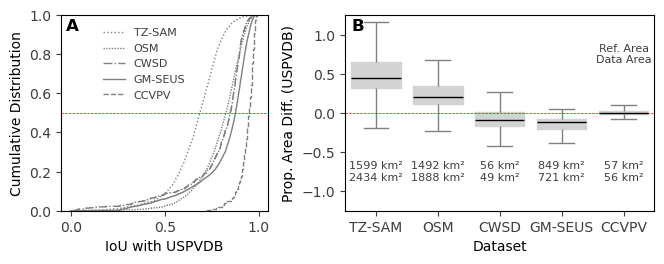

In [ ]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Make the Plot ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ #
# Set up the figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(7, 3), gridspec_kw={'width_ratios': [0.4, 0.6]})

# Define line styles and dataset order
line_styles = [':', (0, (1, 1)), '-.', '-', '--']  # Adjusted styles for left to right solidity
dataset_order = ['TZ-SAM', 'OSM', 'CWSD', 'GM-SEUS', 'CCVPV']
#palette = sns.color_palette('Set1', len(dataset_order))  # Define consistent colors
gray_shade = "lightgray"  # Color for boxplots

# Left Plot: Cumulative Distribution Plot (IoU on x-axis)
for i, name in enumerate(dataset_order):
    group = all_data[all_data['Name'] == name]
    sns.ecdfplot(data=group, x="IoU", ax=axes[0], label=name, linestyle=line_styles[i], color='gray', linewidth=1)

# Add 50% cumulative distribution line
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=0.5) #, label='50% Cumulative'
axes[0].set_xlabel('IoU with USPVDB', fontsize=10, color='black')
axes[0].set_ylabel('Cumulative Distribution', fontsize=10, color='black')
#axes[0].set_title('Cumulative IoU Distribution')
#axes[0].legend(loc='center', bbox_to_anchor=(0.25, 0.75), frameon=False, fontsize=8)  # Center legend at (0.25, 0.5)
#axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Adjust legend with no background, font size 8, and text color
legend = axes[0].legend(loc='center', bbox_to_anchor=(0.32, 0.75), frameon=False, fontsize=8)  # Legend text size 8
for text in legend.get_texts():
    text.set_color(darkGreyTheme)  # Set legend text color to #3D3D3D

# Add "A" label in the lower left corner
axes[0].text(0.02, 0.98, 'A', transform=axes[0].transAxes, ha='left', va='top', fontsize=12, weight='bold')

# Right Plot: Boxplot for Proportional Difference
sns.boxplot(data=all_data, x='Name', y='propDiff', order=dataset_order, 
    boxprops=dict(color=gray_shade),  # Apply gray shade to boxplots
    whiskerprops=dict(color="gray"),  # Make whiskers dark gray
    capprops=dict(color="gray"),  # Make caps dark gray
    medianprops=dict(color="black"),  # Ensure median line is black
    showfliers=False, ax=axes[1])

# Add total sum of areaA and areaB in km² for each dataset
axes[1].text(4, 0.75, f"Ref. Area\nData Area", ha='center', va='center', fontsize=8, color = darkGreyTheme)
for i, name in enumerate(dataset_order):
    total_areaA_km2 = int(round(all_data[all_data['Name'] == name]['areaA'].sum() / 1e6, 0))
    total_areaB_km2 = int(round(all_data[all_data['Name'] == name]['areaB'].sum() / 1e6, 0))
    axes[1].text(i, -0.75, f"{total_areaA_km2} km²\n{total_areaB_km2} km²", ha='center', va='center', fontsize=8, color = darkGreyTheme)

# Add labels, title, and set y-axis limits
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.5)  # Add a reference line at 0
axes[1].set_ylim(-1.25, 1.25)  # Set limits from -1.25 to 1.25
#axes[1].set_title('Proportional Array Area Difference by Dataset')
axes[1].set_xlabel('Dataset', fontsize=10, color='black')
axes[1].set_ylabel('Prop. Area Difference', fontsize=10, color='black')
#axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Add "A" label in the lower left corner
axes[1].text(0.02, 0.98, 'B', transform=axes[1].transAxes, ha='left', va='top', fontsize=12, weight='bold')

# Change axis text to dark gray
for ax in axes:
    ax.tick_params(axis='x', colors=darkGreyTheme)  # Set x-axis tick labels to dark gray
    ax.tick_params(axis='y', colors=darkGreyTheme)  # Set y-axis tick labels to dark gray

# Adjust layout
plt.tight_layout(pad=2.0)  # Add padding between subplots
plt.subplots_adjust(wspace=0.3)  # Increase spacing between the two plots

# Save the figure
plt.savefig(os.path.join(figure_path, 'IoU_ProportionalDifference.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_path, 'IoU_ProportionalDifference.pdf'), dpi=300, bbox_inches='tight')

# Adjust layout and display
#plt.tight_layout()
plt.show()

## Panel-Rows IoU

### Get Numbers

In [44]:
# Get the IOU of NAIP panels relative to existing
naipPanelsIOU = getIoU(gmseusPanelsExisting, gmseusPanelsNAIP, True)

# Set name
naipPanelsIOU['Name'] = 'NAIP Panel-Rows'

# Print median IoU
print('GM-SEUS NAIP Median IoU: ', naipPanelsIOU['IoU'].median())

# Print the median proportional difference for NAIP panels
print('GM-SEUS NAIP Median Proportional Panel Area Difference: ', naipPanelsIOU['propDiff'].median())

# Print the length of naipPanelsIOU
print('Number of Intersections in naipPanelsIOU: ', len(naipPanelsIOU))

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Get arrays from panels

# Now, we need to create array from panels, selecting intersecting new arrays (we've already done this for NAIP panels)
naipArraysFromPanels = gpd.read_file(gmseusNaipArraysPath)

# Now, add a pnlIntersectID column to naipArraysFromPanels
naipArraysFromPanels['pnlIntersectID'] = range(1, len(naipArraysFromPanels) + 1) 

# Address existing panels
# Set the rowArea column to the area of the panel
# Spatially join gmseus arrays to panels, copy the pnlIntersectID to the panels, and drop the index columns. 
gmseusPanelsExisting = gmseusPanelsExisting.drop(columns=['pnlIntersectID', 'rowArea'], errors='ignore')
gmseusPanelsExisting['rowArea'] = gmseusPanelsExisting['geometry'].area
gmseusPanelsExisting = gpd.sjoin(gmseusPanelsExisting, naipArraysFromPanels[['pnlIntersectID', 'geometry']], how='left', predicate='intersects')
gmseusPanelsExisting  = gmseusPanelsExisting.reset_index(drop=True)
gmseusPanelsExisting  = gmseusPanelsExisting.drop(columns=['index_left', 'index_right'], errors='ignore')
existingArraysFromPanels = createArrayFromPanels(gmseusPanelsExisting, panelArrayBuff, 'pnlIntersectID', 'rowArea')

# Now create a new gdf comparePanelArea with pnlIntersectID, area, and nativeID
naipArraysFromPanels = naipArraysFromPanels[['pnlIntersectID', 'pnlArea']]
naipArraysFromPanels = naipArraysFromPanels.rename(columns = {'pnlArea': 'pnlAreaNAIP'})
existingArraysFromPanels = existingArraysFromPanels[['pnlIntersectID', 'pnlArea']]
comparePanelArea = naipArraysFromPanels.merge(existingArraysFromPanels, on = 'pnlIntersectID', how = 'left')

# Add a propDiff column to comparePanelArea and a Name column
comparePanelArea['propDiff'] = (comparePanelArea['pnlAreaNAIP'] - comparePanelArea['pnlArea']) / comparePanelArea['pnlArea']
comparePanelArea['Name'] = 'NAIP Panel-Rows'

GM-SEUS NAIP Median IoU:  0.47830381837999314
GM-SEUS NAIP Median Proportional Panel Area Difference:  0.15129397927683685
Number of Intersections in naipPanelsIOU:  361174


### Get Figure

f:\Python_Envs\BigPanel\Lib\site-packages\seaborn\categorical.py:700: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  artists = ax.bxp(**boxplot_kws)


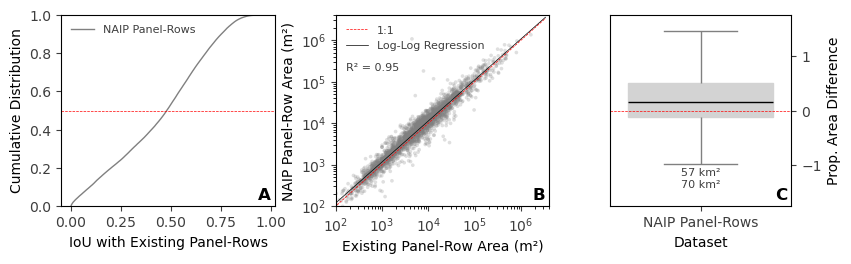

In [87]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Make the Plot ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ #
# Set up the figure
fig, axes = plt.subplots(1, 3, figsize=(9, 3), gridspec_kw={'width_ratios': [1, 1, 0.85]})

# Define line style and color
line_style = '-'
line_color = 'gray'
gray_shade = "lightgray"

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Subplot A

# Left Plot: Cumulative Distribution Plot (IoU on x-axis)
sns.ecdfplot(data=naipPanelsIOU, x="IoU", ax=axes[0], label='NAIP Panel-Rows', linestyle=line_style, color=line_color, linewidth=1)

# Add 50% cumulative distribution line
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=0.5)
axes[0].set_xlabel('IoU with Existing Panel-Rows', fontsize=10, color='black')
axes[0].set_ylabel('Cumulative Distribution', fontsize=10, color='black')

# Adjust legend with no background, font size 8, and text color
legend = axes[0].legend(loc='upper left', frameon=False, fontsize=8)
for text in legend.get_texts():
    text.set_color(darkGreyTheme)  # Set legend text color to #3D3D3D

# Add "A" label in the lower left corner
axes[0].text(0.98, 0.02, 'A', transform=axes[0].transAxes, ha='right', va='bottom', fontsize=12, weight='bold')

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Subplot B

# Middle Plot: Scatterplot for areaA (x) and areaB (y) in log-log scale (I want no edge color). Set size to 0.3
axes[1].scatter(comparePanelArea['pnlArea'], comparePanelArea['pnlAreaNAIP'], alpha=0.25, edgecolors='none', color='gray', s=7)

# Add reference line (y=x) for comparison
max_val = max(comparePanelArea['pnlArea'].max(), comparePanelArea['pnlAreaNAIP'].max())
min_val = min(comparePanelArea['pnlArea'].min(), comparePanelArea['pnlAreaNAIP'].min())
axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=0.5, label='1:1')

# Get the loglog R2 value and add it in the upper left
# Get comparePanelArea where pnlArea and pnlAreaNAIP are greater than 0
comparePanelAreaR2 = comparePanelArea[(comparePanelArea['pnlArea'] > 0) & (comparePanelArea['pnlAreaNAIP'] > 0)]
r2 = np.corrcoef(np.log10(comparePanelAreaR2['pnlArea']), np.log10(comparePanelAreaR2['pnlAreaNAIP']))[0, 1] ** 2
axes[1].text(0.05, 0.75, f'R² = {r2:.2f}', transform=axes[1].transAxes, ha='left', va='top', fontsize=8, color=darkGreyTheme)

# Add loglog linear regression line
slope, intercept = np.polyfit(np.log10(comparePanelAreaR2['pnlArea']), np.log10(comparePanelAreaR2['pnlAreaNAIP']), 1)
axes[1].plot([min_val, max_val], [10**intercept * min_val ** slope, 10**intercept * max_val ** slope], color='black', linestyle='-', linewidth=0.5, label='Log-Log Regression')

# Add legend in the upper left and set text color
legend = axes[1].legend(loc='upper left', frameon=False, fontsize=8)
for text in legend.get_texts():
    text.set_color(darkGreyTheme)  # Set legend text color to #3D3D3D

# Set log-log scale
axes[1].set_xscale('log')
axes[1].set_yscale('log')

# Add labels, title, and format axes
axes[1].set_xlabel('Existing Panel-Row Area (m²)', fontsize=10, color='black')
axes[1].set_ylabel('NAIP Panel-Row Area (m²)', fontsize=10, color='black')
axes[1].set_xlim([1e2, max_val * 1.2])  # Adjust limits to fit data
axes[1].set_ylim([1e2, max_val * 1.2])

# Add "B" label in the upper left
axes[1].text(0.98, 0.02, 'B', transform=axes[1].transAxes, ha='right', va='bottom', fontsize=12, weight='bold')

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Subplot C

# Right Plot: Boxplot for Proportional Difference
sns.boxplot(
    data=naipPanelsIOU,
    x='Name',
    y='propDiff',
    boxprops=dict(color=gray_shade),  # Apply gray shade to boxplots
    whiskerprops=dict(color="gray"),  # Make whiskers dark gray
    capprops=dict(color="gray"),  # Make caps dark gray
    medianprops=dict(color="black"),  # Ensure median line is black
    showfliers=False,
    ax=axes[2])

# Add total sum of pnlArea and pnlAreaNAIP in km²
total_areaA_km2 = int(round(naipPanelsIOU['areaA'].sum() / 1e6, 0))
total_areaB_km2 = int(round(naipPanelsIOU['areaB'].sum() / 1e6, 0))
axes[2].text(0, -1.25, f"{total_areaA_km2} km²\n{total_areaB_km2} km²", ha='center', va='center', fontsize=8, color=darkGreyTheme)

# Add labels, title, and set y-axis limits
axes[2].axhline(0, color='red', linestyle='--', linewidth=0.5)  # Add a reference line at 0
axes[2].set_ylim(-1.75, 1.75)  # Set limits from -1.5 to 1.5
axes[2].set_ylabel('')  # Remove default y-axis label
axes[2].yaxis.tick_right()  # Move y-axis ticks to the right
axes[2].yaxis.set_label_position('right')  # Move y-axis label to the right
axes[2].set_ylabel('Prop. Area Difference', fontsize=10, color='black')  # Add y-axis label on the right
axes[2].set_xlabel('Dataset', fontsize=10, color='black')

# Add "B" label in the upper left
axes[2].text(0.98, 0.02, 'C', transform=axes[2].transAxes, ha='right', va='bottom', fontsize=12, weight='bold')

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Adjust layout

# Change axis text to dark gray
for ax in axes:
    ax.tick_params(axis='x', colors=darkGreyTheme)  # Set x-axis tick labels to dark gray
    ax.tick_params(axis='y', colors=darkGreyTheme)  # Set y-axis tick labels to dark gray

# Adjust layout. I want plot a and b to be normally spaced and plot b and C to be touching
plt.tight_layout(pad=2.0)  # Add padding between subplots
plt.subplots_adjust(wspace=0.3)  # Increase spacing between the two plot

# # Save the figure
plt.savefig(os.path.join(figure_path, 'PanelRows_IoU_ProportionalDifference.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_path, 'PanelRows_IoU_ProportionalDifference.pdf'), dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

In [79]:
# Now, we need to create array from panels, selecting intersecting new arrays (we've already done this for NAIP panels)
naipArrays = gpd.read_file(gmseusNaipArraysPath)

# Print head of comparePanelArea where propDiff is greater than 200
print(comparePanelArea[comparePanelArea['propDiff'] > 200])

# Get pnlAreaNAIP of comparePanelArea where propDiff is greater than 200
largePnlArea = int(comparePanelArea[comparePanelArea['propDiff'] > 200]['pnlAreaNAIP'])

# Subset naipArrays for where pnlArea is == largePnlArea
testArray = naipArrays[naipArrays['pnlArea'] == largePnlArea]

# Print head
print(testArray.head())


      pnlIntersectID   pnlAreaNAIP      pnlArea    propDiff             Name
4901            4902  1.073086e+06  4421.869842  241.676985  NAIP Panel-Rows
Empty GeoDataFrame
Columns: [subArrID, arrayID, nativeID, Source, pnlNum, area, mount, azimuth, lengthRati, shortEdge, longEdge, QAQC, perimeter, PmArRatio, compactnes, areaRatio, numPanels, pnlArea, arrayArea, geometry]
Index: []


C:\Users\stidjaco\AppData\Local\Temp\ipykernel_37560\776975546.py:8: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  largePnlArea = int(comparePanelArea[comparePanelArea['propDiff'] > 200]['pnlAreaNAIP'])


# Supplementary Info

In [9]:
# Get list of images in imagesPath
image_files = glob.glob(os.path.join(imagesPath, '*.tif'))

# Print total number of images
print(f"Total number of images: {len(image_files)}")

# Extract arrayID from each filename. array_id is the integer value between 'id' and '.tif', but can also look like this id14432-0000000000-0000000000.tif where the arrayID is 14432
arrayIDs = []
for f in image_files:
    match = re.search(r'id(\d+)', f)
    if match:
        array_id = int(match.group(1))
        arrayIDs.append(array_id)

# Get the number of unique arrayIDs
num_unique_arrayIDs = len(set(arrayIDs))

# Print the number of unique arrayIDs
print(f"Number of unique arrayIDs in labeled imagery : {num_unique_arrayIDs}")

Total number of images: 17432
Number of unique arrayIDs in labeled imagery : 4452


# ARCHIVE

## Prep GMSEUS Arrays and Panels for GEE upload

In [4]:
# # Call gmseus arrays and panels
# gmseusArrays = gpd.read_file(gmseusArraysFinalPath)
# gmseusPanels = gpd.read_file(gmseusPanelsFinalPath)

# # Transform gmseusArrays and panels to EPSG:4326 (WGS84) -- native GEE projection
# gmseusArrays = gmseusArrays.to_crs(geeCRS)
# gmseusPanels = gmseusPanels.to_crs(geeCRS)

# # Export to intermediateProducts folder
# gmseusArrays.to_file(os.path.join(derivedTemp_path, 'GMSEUS_Arrays_Final4326.shp'), driver='ESRI Shapefile')
# gmseusPanels.to_file(os.path.join(derivedTemp_path, 'GMSEUS_Panels_Final4326.shp'), driver='ESRI Shapefile')

## Old Installation Year Plot

In [ ]:
# # Call gmseusArrays
# gmseusArrays = gpd.read_file(gmseusArraysFinalPath)

# # Set plot df (Source 'USPVDB' or 'CCVPV')
# plotdf = gmseusArrays[gmseusArrays['Source'].isin(['USPVDB'])]

# # Calculate the deviation
# plotdf['deviation'] = plotdf['instYrLT'] - plotdf['instYr']

# # Remove any rows where instYrLT is -9999 or instYr is -9999
# lt_data_noNull = plotdf[(plotdf['instYrLT'] != -9999) & (plotdf['instYr'] != -9999)]

# # Drop rows where Source is anything other than USPVDB
# lt_data_noNull = lt_data_noNull[lt_data_noNull['Source'] == 'USPVDB']

# # Print the total number of arrays with a newly detected installation year
# print('Number of arrays with a newly detected installation year:', lt_data_noNull['deviation'].value_counts().sum())

# # Print the mean absolute deviation
# print('Mean Absolute Error:', lt_data_noNull['deviation'].abs().mean())

# # Create a list of deviation values grouped by instYr and count the number of data points in each group
# data = [lt_data_noNull[lt_data_noNull['instYr'] == year]['deviation'] for year in range(2009, 2024)]
# counts = [len(group) for group in data]

# # Plot the boxplot without showing outliers
# plt.figure(figsize=(10, 4.5))
# # Add a shaded black (alpha = 0.25) that is plus or minus 1 year from the 0 line
# plt.axhspan(-1, 1, color='black', alpha=0.25, label='±1 Year Deviation')

# # Create the boxplot
# plt.boxplot(data, positions=range(2009, 2024), widths=0.5, showfliers=False)

# # Add the count (N) above each box
# for i, count in enumerate(counts):
#     plt.text(2009 + i, 5, f'n={count}', ha='center', va='bottom', fontsize=10)

# # In the lower left corner, add the MAE and the difference between lt_data nrows with instYr and instYrLT values not equal to -9999 and source USPVDB, and the nrows of lt_data_noNull
# plt.text(2009, -7, f'MAE = {lt_data_noNull["deviation"].abs().mean():.2f}', ha='left', va='top', fontsize=10)
# plt.text(2009, -8.5, f'Missing Arrays = {plotdf[(plotdf['instYr'] != -9999) & (plotdf["Source"] == "USPVDB")].shape[0] - lt_data_noNull.shape[0]}', ha='left', va='top', fontsize=10)

# # Set x and y limits
# plt.xlim(2008.5, 2023.5)
# plt.ylim(-13, 13)

# # Add labels, title, and grid
# plt.xlabel('instYr', fontsize=12)
# plt.ylabel('Deviation (instYrLT - instYr)', fontsize=12)
# plt.title('LandTrendr Installation Year Accuracy', fontsize=14)
# plt.grid(axis='y', linestyle='--', alpha=0.7)

# # Add a 0 line (no deviation)
# plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='No Deviation')

# # Add a legend
# plt.legend()

# # Show the plot
# plt.tight_layout()
# plt.show()

## Old Capacity Plot

In [ ]:
# # Call gmseusArrays and CCVPV arrays
# gmseusArrays = gpd.read_file(gmseusArraysFinalPath)

# # First version of plotdf (Source = 'USPVDB')
# plotdf1 = gmseusArrays[gmseusArrays['Source'].isin(['USPVDB'])]
# plotdf1['capMW'] = np.log10(plotdf1['capMW'])
# plotdf1['capMWest'] = np.log10(plotdf1['capMWest'])

# # Second version of plotdf (modType = 'CSP')
# plotdf2 = gmseusArrays[gmseusArrays['modType'] == 'csp']
# plotdf2['capMW'] = np.log10(plotdf2['capMW'])
# plotdf2['capMWest'] = np.log10(plotdf2['capMWest'])

# # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Calculate statistics and plot
# fig, axes = plt.subplots(1, 2, figsize=(7, 4), sharex=True, sharey=True)  # Side-by-side plots

# # Function to plot regression plots with statistics
# def regression_with_stats(ax, data, title):
#     # Regression plot with confidence interval
#     sns.regplot(x='capMW', y='capMWest', data=data, ax=ax, scatter_kws={'alpha': 0.5}, 
#                 line_kws={'color': 'red'}, ci=95)
    
#     # 1:1 line
#     ax.plot([0, 3.1], [0, 3.1], color='black', linestyle='--', label='1:1 Line')
    
#     # Grid and styling
#     ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    
#     # Calculate statistics
#     rmse = np.sqrt(((data['capMW'] - data['capMWest'])**2).mean())
#     mae = (data['capMW'] - data['capMWest']).abs().mean()
#     r2 = 1 - ((data['capMW'] - data['capMWest'])**2).sum() / ((data['capMW'] - data['capMW'].mean())**2).sum()
    
#     # Add statistics text
#     ax.text(0.25, 2.5, f'Log-RMSE = {rmse:.2f}', fontsize=8)
#     ax.text(0.25, 2.25, f'Log-MAE = {mae:.2f}', fontsize=8)
#     ax.text(0.25, 2.00, f'Log-R2 = {r2:.2f}', fontsize=8)
    
#     # Axes limits and title
#     ax.set_xlim(0, 3.1)
#     ax.set_ylim(0, 3.1)
#     ax.set_title(title, fontsize=10)
    
#     # Log-scale ticks
#     def log_tick_formatter(val, pos):
#         return f"$10^{{{int(val)}}}$"

#     ax.xaxis.set_major_locator(ticker.MultipleLocator(base=1))
#     ax.xaxis.set_major_formatter(ticker.FuncFormatter(log_tick_formatter))
#     ax.yaxis.set_major_locator(ticker.MultipleLocator(base=1))
#     ax.yaxis.set_major_formatter(ticker.FuncFormatter(log_tick_formatter))

#     # Full box around the plot
#     for spine in ax.spines.values():
#         spine.set_visible(True)
#         spine.set_linewidth(1)

#     # Drop x and y titles
#     ax.set_xlabel('')
#     ax.set_ylabel('')

# # Plot first dataframe
# regression_with_stats(axes[0], plotdf1, "Source = 'USPVDB'")

# # Plot second dataframe
# regression_with_stats(axes[1], plotdf2, "modType = 'CSP'")

# # Common axis labels
# fig.text(0.5, 0.04, 'Reported Capacity -- log(MWdc)', ha='center', fontsize=10)
# fig.text(0.02, 0.5, 'Estimated Capacity -- log(MWdc)', va='center', rotation='vertical', fontsize=10)

# # Adjust layout and save
# plt.tight_layout(pad=2.0)
# plt.savefig(os.path.join(figure_path, 'capacityValidation_side_by_side.png'), dpi=300, bbox_inches='tight')
# plt.show()